1. Import Libraries
2. Load Dataset
3. EDA
4. Preprocessing
5. Train-Test Split
6. Feature Scaling
7. Build ANN
8. Compile Model
9. Train Model
10. Plot Loss & Accuracy

<<<<<<<<<<<< INSERT HERE >>>>>>>>>>>>

11. Evaluate Model
12. Confusion Matrix
13. Precision, Recall, F1
14. ROC Curve
15. Precision-Recall Curve

<<<<<<<<<<<< INSERT HERE >>>>>>>>>>>>

16. Build Improved ANN (BatchNorm + Dropout)

<<<<<<<<<<<< INSERT HERE >>>>>>>>>>>>

17. Hyperparameter Experiments

<<<<<<<<<<<< INSERT HERE >>>>>>>>>>>>

18. Compare All Models

<<<<<<<<<<<< INSERT HERE >>>>>>>>>>>>

19. Compare ANN with ML Models

<<<<<<<<<<<< INSERT HERE >>>>>>>>>>>>

20. Save Best Model

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import pickle

In [2]:
# Load the dataset
data = pd.read_csv('Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [5]:
data.describe(include='all')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [6]:
# Preprocess the data
# Drop irrelevant columns
data = data.drop(['RowNumber','CustomerId','Surname'],axis=1)
data.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
data['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
data['HasCrCard'].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

In [10]:
## Encode categorical variables
label_encoder_gender = LabelEncoder()
data['Gender'] = label_encoder_gender.fit_transform(data['Gender'])
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [11]:
data['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
## Onehot encode Geography
geography_ohe = OneHotEncoder(drop='first', sparse_output=False)

geo_encoded = geography_ohe.fit_transform(data[['Geography']])

geo_encoded_df = pd.DataFrame(
    geo_encoded,
    columns=geography_ohe.get_feature_names_out(['Geography']),
    index=data.index
)

## Combine one hot encoder columns with the original data
data = pd.concat(
    [data.drop('Geography', axis=1), geo_encoded_df],
    axis=1
)

data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


In [13]:
## Save the encoder pkl files:
with open('label_encoder_gender.pkl','wb') as file:
    pickle.dump(label_encoder_gender,file)

with open('geography_ohe.pkl','wb') as file:
    pickle.dump(geography_ohe,file)

In [14]:
## DiVide the dataset into indepent and dependent features
X=data.drop('Exited',axis=1)
y=data['Exited']

In [15]:
## Split the data in training and tetsing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
## Scaling features
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [17]:
X_train

array([[ 0.35649971,  0.91324755, -0.6557859 , ...,  1.36766974,
        -0.57946723, -0.57638802],
       [-0.20389777,  0.91324755,  0.29493847, ...,  1.6612541 ,
         1.72572313, -0.57638802],
       [-0.96147213,  0.91324755, -1.41636539, ..., -0.25280688,
        -0.57946723,  1.73494238],
       ...,
       [ 0.86500853, -1.09499335, -0.08535128, ..., -0.1427649 ,
        -0.57946723, -0.57638802],
       [ 0.15932282,  0.91324755,  0.3900109 , ..., -0.05082558,
        -0.57946723, -0.57638802],
       [ 0.47065475,  0.91324755,  1.15059039, ..., -0.81456811,
         1.72572313, -0.57638802]])

In [18]:
## Save the Scaler pkl files:
with open('scaler.pkl','wb') as file:
    pickle.dump(scaler,file)

In [19]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


## ANN Implementation

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [21]:
X_train.shape[1],1

(11, 1)

In [22]:
## Build our ANN Model
model = Sequential([
    Dense(64,activation='relu',input_shape = (X_train.shape[1],)),  ## HL1 Connected wwith input layer
    Dense(32,activation='relu') , ## HL2
    Dense(1,activation='sigmoid') ## output layer
])

/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-31 15:56:03.174210: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-31 15:56:03.174234: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-07-31 15:56:03.174240: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1785493563.174248  116264 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1785493563.174262  116264 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
## compile the model
opt = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
## setup the tensorboard
log_dir = "logs/baseline_ann/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorflow_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [26]:
## Set up early stopping
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [27]:
### Train the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[tensorflow_callback, early_stopping_callback]
)

Epoch 1/100


2026-07-31 15:56:03.455250: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6741 - loss: 0.6131 - val_accuracy: 0.7588 - val_loss: 0.5302
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7862 - loss: 0.5041 - val_accuracy: 0.8081 - val_loss: 0.4631
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7997 - loss: 0.4616 - val_accuracy: 0.8144 - val_loss: 0.4351
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8045 - loss: 0.4450 - val_accuracy: 0.8206 - val_loss: 0.4253
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8045 - loss: 0.4391 - val_accuracy: 0.8206 - val_loss: 0.4223
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8067 - loss: 0.4373 - val_accuracy: 0.8225 - val_loss: 0.4209
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8077 - loss: 0.4363 - val_accuracy: 0.8181 - val_loss: 0.4204
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8072 - loss: 0.4368 - val_accuracy: 0.8244

In [28]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 0.4157
Test Accuracy : 0.8135


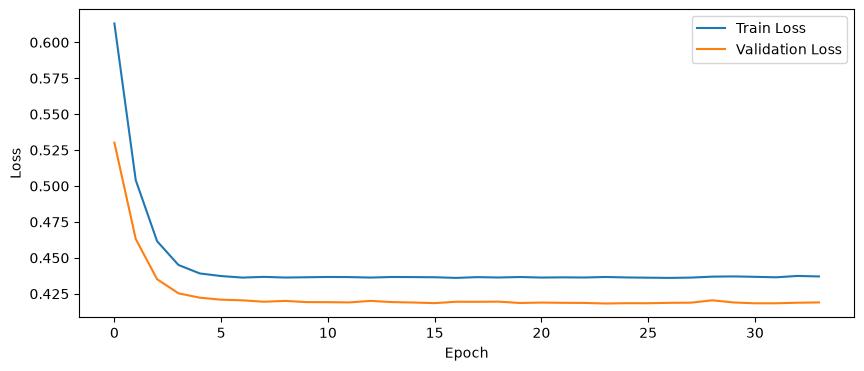

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

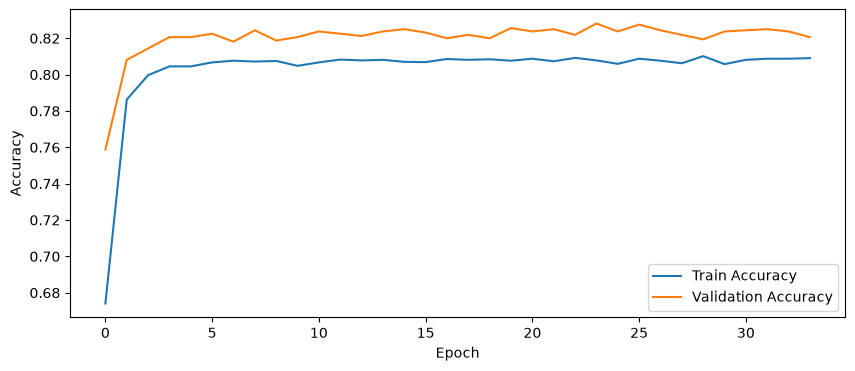

In [30]:
plt.figure(figsize=(10, 4))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 12. Model Evaluation

The model is evaluated on the unseen test dataset using multiple classification metrics.

The metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Classification Report

Using multiple metrics provides a better understanding of the model's performance than relying on accuracy alone, especially for imbalanced datasets such as Customer Churn Prediction.

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Predict probabilities
y_prob = model.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_prob >= 0.5).astype(int)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("="*50)
print("Baseline ANN Performance")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Baseline ANN Performance
Accuracy : 0.8135
Precision: 0.5758
Recall   : 0.1934
F1 Score : 0.2895
ROC AUC  : 0.7764


## Classification Report

The classification report provides detailed performance metrics for each class.

It contains:

- Precision
- Recall
- F1-score
- Support

This helps identify whether the model performs equally well for both churned and non-churned customers.

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.58      0.19      0.29       393

    accuracy                           0.81      2000
   macro avg       0.70      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



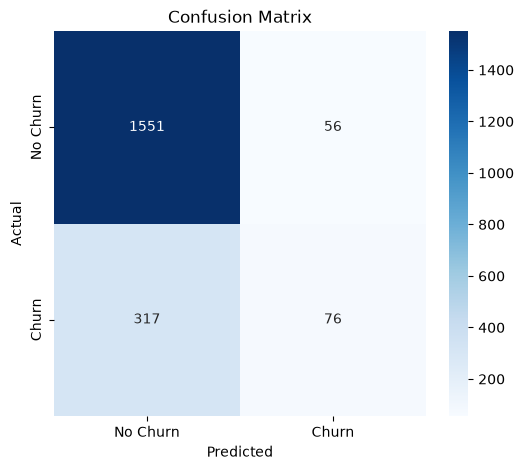

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

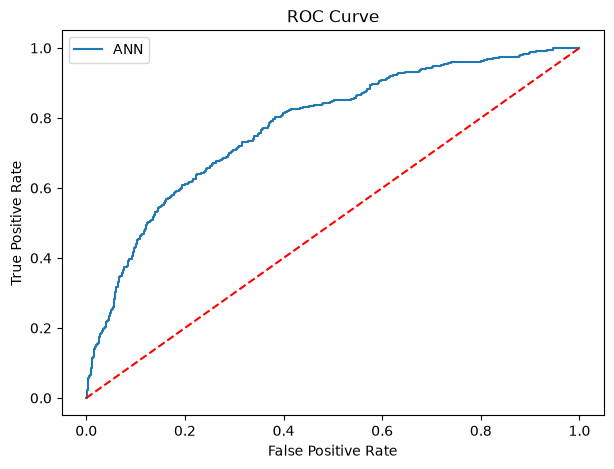

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label="ANN")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

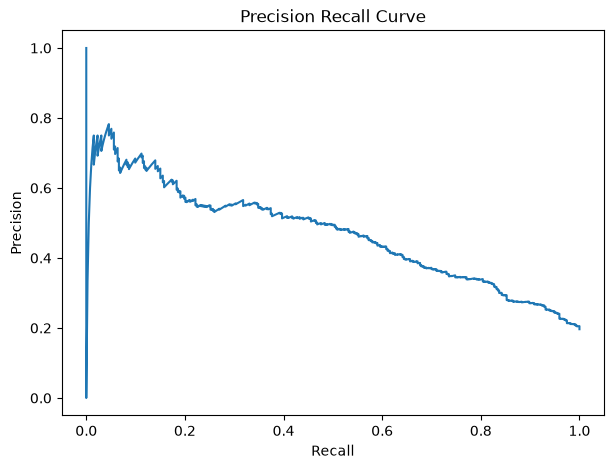

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test,y_prob)

plt.figure(figsize=(7,5))

plt.plot(recall,precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout

model2 = Sequential()

model2.add(Dense(64,activation='relu',input_dim=11))
model2.add(BatchNormalization())
model2.add(Dropout(0.30))

model2.add(Dense(32,activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.20))

model2.add(Dense(1,activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
log_dir = "logs/improved_ann/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

improved_tensorboard = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [38]:
history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[improved_tensorboard, early_stopping_callback]
)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7306 - loss: 0.5542 - val_accuracy: 0.8181 - val_loss: 0.4281
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7898 - loss: 0.4769 - val_accuracy: 0.8144 - val_loss: 0.4233
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7997 - loss: 0.4557 - val_accuracy: 0.8156 - val_loss: 0.4247
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8023 - loss: 0.4570 - val_accuracy: 0.8150 - val_loss: 0.4219
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7983 - loss: 0.4546 - val_accuracy: 0.8206 - val_loss: 0.4277
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8016 - loss: 0.4542 - val_accuracy: 0.8087 - val_loss: 0.4309
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8023 - loss: 0.4535 - val_accuracy: 0.8131 - val_loss: 0.4255
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7994 - loss: 0.4567 - 

In [39]:
architectures = {

"Model A":[64,32],
"Model B":[128,64],
"Model C":[64,32,16],
"Model D":[128,64,32]

}

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, layers in architectures.items():

    model_exp = Sequential()

    model_exp.add(
        Dense(
            layers[0],
            activation="relu",
            input_dim=X_train.shape[1]
        )
    )

    for neurons in layers[1:]:
        model_exp.add(
            Dense(
                neurons,
                activation="relu"
            )
        )

    model_exp.add(
        Dense(
            1,
            activation="sigmoid"
        )
    )

    model_exp.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
    
    log_dir = f"logs/architecture/{name}/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    architecture_tensorboard = TensorBoard(
        log_dir=log_dir,
        histogram_freq=1
    )

    history = model_exp.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        verbose=0,
        callbacks=[
            architecture_tensorboard,
            early_stop
        ]
    )

    y_prob = model_exp.predict(X_test, verbose=0)

    y_pred = (y_prob >= 0.5).astype(int)

    results.append({

        "Architecture": name,

        "Accuracy":
        accuracy_score(y_test, y_pred),

        "Precision":
        precision_score(y_test, y_pred),

        "Recall":
        recall_score(y_test, y_pred),

        "F1 Score":
        f1_score(y_test, y_pred),

        "ROC-AUC":
        roc_auc_score(y_test, y_prob),

        "Epochs":
        len(history.history["loss"])

    })

/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the

In [41]:
comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison

,Architecture,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Epochs
0,Model A,0.8125,0.568182,0.190840,0.285714,0.779039,11
2,Model C,0.8075,0.520202,0.262087,0.348562,0.776664,11
1,Model B,0.8180,0.547855,0.422392,0.477011,0.746766,11
3,Model D,0.8115,0.540000,0.274809,0.364250,0.737989,11


# Architecture Comparison

Four different Artificial Neural Network architectures were evaluated.

Each model was trained using:

- Adam Optimizer
- Binary Crossentropy Loss
- Early Stopping
- Validation Split = 20%

The models were compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Number of Epochs before Early Stopping

The architecture with the highest ROC-AUC was selected as the best-performing model.

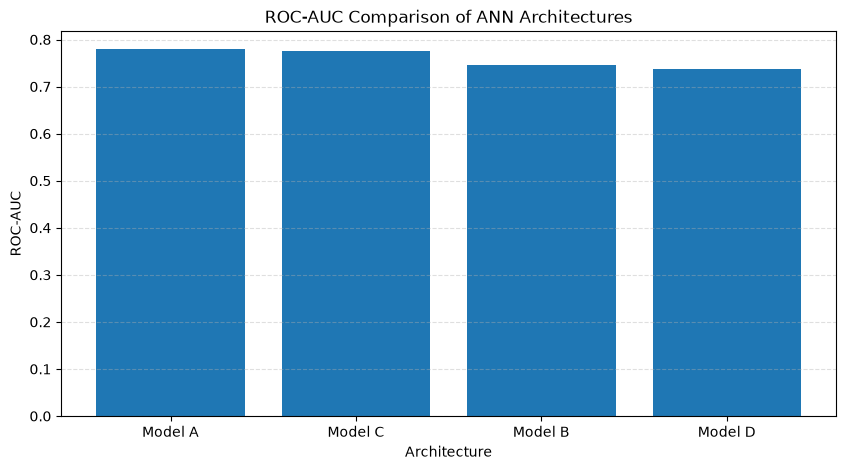

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    comparison["Architecture"],
    comparison["ROC-AUC"]
)

plt.title("ROC-AUC Comparison of ANN Architectures")

plt.xlabel("Architecture")

plt.ylabel("ROC-AUC")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [44]:
models={

"Logistic Regression":
LogisticRegression(),

"Random Forest":
RandomForestClassifier(),

"XGBoost":
XGBClassifier(),

}

In [45]:
ml_results=[]

for name,clf in models.items():

    clf.fit(X_train,y_train)

    pred=clf.predict(X_test)

    ml_results.append([

        name,

        accuracy_score(y_test,pred),

        precision_score(y_test,pred),

        recall_score(y_test,pred),

        f1_score(y_test,pred)

    ])

/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:356: RuntimeWarning: divide by zero encountered in matmul
  X_grad = X.T @ grad_pointwise
/Users/milind/Downloads/ANN_Classification/venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:356: RuntimeWarning: overf

In [46]:
ml_results.append([

"ANN",

accuracy_score(y_test,y_pred),

precision_score(y_test,y_pred),

recall_score(y_test,y_pred),

f1_score(y_test,y_pred)

])

In [47]:
comparison_df=pd.DataFrame(

ml_results,

columns=[

"Model",

"Accuracy",

"Precision",

"Recall",

"F1"

]

)

comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,XGBoost,0.8695,0.717105,0.554707,0.625538
1,Random Forest,0.8650,0.746988,0.473282,0.579439
3,ANN,0.8115,0.540000,0.274809,0.364250
0,Logistic Regression,0.8110,0.552448,0.201018,0.294776


In [48]:
model2.save("customer_churn_ann.keras")

In [49]:
model.save('model.h5')

In [50]:
%load_ext tensorboard
%tensorboard --logdir logs